# How to Decide on Boundaries for Difference and Equivalence

- **License:** [MIT License](https://opensource.org/licenses/MIT)
- **Version:** 0.4
- **Edit Log:** 
    - 2024-04-10: Initial version of the notebook
    - 2024-04-12: More intricate simulation suite is included (Removed)
    - 2024-04-15: Simpler real data only examples are included
    - 2025-04-23: Further details and clean-up of the notebook

**Data Information:**

The data used in this notebook will be using datasets from both spiked-in and cancer cell line datasets as well as simulated datasets to highlight the importance and how we can decide on the boundaries for equivalence and difference.

**Notebook Summary:**

In this notebook I will be explaining methods to determine log2 fold-change upper and lower boundaries for equivalence testing and difference testing. The main method we recommend when determining the boundaries is to first establish the equivalence testing that can be as small as the data can allow and then determine the difference testing larger than that of equivalence testing. Here I will be showing how the sample size and the intra-sample CV can be used to determine the boundaries with the help of simulated datasets and real datasets.

## Setup Notebook

This part is a standard for my notebooks, where I import the all used libraries, set the design of the notebook, and define the paths for data and figures. 

> **Note:** The HTML rendering of this notebook will not show the code cells by default, but the code can be visible by clicking the "code" buttons aligned on the right.

### Libraries Used

In [1]:
import os
import sys
import feather
import warnings
from multiprocessing import Pool # Multiprocessing

import numpy as np 
import pandas as pd 

import seaborn as sns # R-like high-level plots
import matplotlib.pyplot as plt # Python's base plotting 

sys.path.append('../')
# Custom functions
from questvar import plots, utils, test

warnings.filterwarnings('ignore')

nbStartTime = utils.getTime()

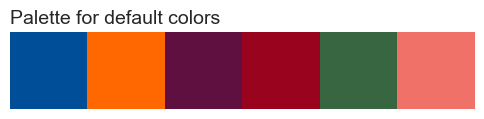

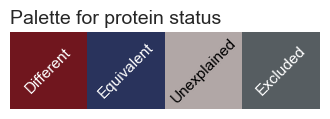

In [2]:
### Notebook Configuration

# Colors
def_colors = [
    '#004e98', '#ff6700', '#5f0f40', '#9a031e', '#386641', '#f07167'
]

# Color dict for the protein status
status_colors = {
    "Different": "#70161e",
    "Equivalent": "#29335c",
    "Unexplained": "#b1a7a6",
    "Excluded": "#565d61"
}

## Configure some general styling

# Set seaborn style
sns.set_theme(
    style="white",
    context="paper",
    palette=def_colors,
    font_scale=1,
    rc={
        "figure.figsize": (6, 4),
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
    }
)

# Figure Saving Settings
figure_formats = ["png", "pdf"]
save_to_folder = True
transparet_bg = True
figure_dpi = 300

## Configure dataframe displaying

pd.set_option('display.float_format', lambda x: '%.4f' % x)
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 25)

# Metric colors
plots.color_palette(
    def_colors,
    name = "default colors"
)

# Protein status colors
plots.color_palette(
    status_colors,
    name = "protein status"
)

In [3]:
# Establish the paths

notebook_name = "boundaryDecision"                  # Notebook name
data_path = "./data/"                               # Data folder
fig_path = f"./figures/{notebook_name}/"            # Figures folder


# Create figure folder structure, if needed
if save_to_folder:
    for i in figure_formats:
        cur_folder = fig_path + i + "/"
        if not os.path.exists(cur_folder):
            os.makedirs(cur_folder)

## Spiked-in Data

When it comes to determining what constitudes a significant difference or equivalence, it is important to understand the data and the biological context. Prior to data creation, it is important to establish the the expected biological differences and lay out the data precision expected from the experiment. These rules will be the main source in determining the boundaries. 

However the datasets we have for the analysis is not our own and we had to rely on the data itself to determine the boundaries. In that cases the sample-size and the intra-sample CV can be provide a way to approximate the boundaries especially for equivalence. 


### Sampling Tehnical Replicates to Determine Equivalence Boundaries

In the cases where the biological difference is not known, we can use the technical replicates to determine the boundaries for equivalence testing. The technical replicates are the same samples that are measured multiple times to determine the data precision. The data precision can be determined by calculating the coefficient of variation (CV) within the technical replicates. The CV is calculated by dividing the standard deviation of the technical replicates by the mean of the technical replicates.

For the first demonstration I will use th reference sample (1-06) comes from E. coli spiked-in data, that is filtered to have only fully quantified proteins left. First I want to show the the variation from the data can be observed from the comparison of two technical replicate subsets from the same biological sample. To highlight I randomly picked 10 columns from the reference sample without replacement and plotted an MA plot to show the variation between the two subsets.

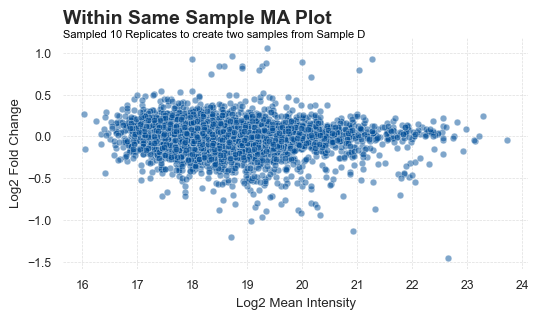

In [4]:
sample_name = "1-06"
new_name = "Sample D"
reference_data = feather.read_dataframe(
    f"../2022_Frohlich/data/processed/samples/{sample_name}.feather"
).dropna()
reference_cv_dist = utils.cv_numpy(
    x = reference_data.values,
    format = "ratio"
)

reference_dist = (reference_data.mean(axis=1))


nReps = 10
# Randomly split the list into two
cols = reference_data.columns.tolist()
# Select randomly the number of samples without overlap divided by 2
sample1 = np.random.choice(cols, nReps, replace=False)
sample2 = np.random.choice(list(set(cols) - set(sample1)), nReps, replace=False)
assert len(set(sample1).intersection(set(sample2))) == 0, "Overlap between samples"

data1 = reference_data[sample1]
data2 = reference_data[sample2]

# Initialize the figure
fig, ax = plt.subplots(
    figsize=(6, 3)
)

# Plot MA plot
sns.scatterplot(
    x = np.log2(reference_data[sample1].mean(axis=1)),
    y = np.log2(
        reference_data[sample2].mean(axis=1) / 
        reference_data[sample1].mean(axis=1)
    ),
    color = def_colors[0],
    alpha = 0.5,
    ax = ax
)

ax.set_title(
    "Within Same Sample MA Plot", 
    fontsize=14, 
    fontweight="bold",
    loc="left",
    pad=10
)
# Add annotation
ax.annotate(
    # Add description of the setup
    f"Sampled {nReps} Replicates to create two samples from {new_name}",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax.set_xlabel("Log2 Mean Intensity")
ax.set_ylabel("Log2 Fold Change")

# Add grid
ax.grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "ComparisonSampledReps_MAPlot",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

Even within the same biological sample there are variations that are caused by technical noise and other various contributors. Even though the test between randomly selected 10 technical replicates against another 10 technical replicates in theory should give us 100% of the proteins to be statistically equivalent with quite a small boundary in reality the technical noise can cause some to be outside of the boundaries or high p-value than the cutoff of 0.05 set. 

#### Effect of Data Quality on Equivalence Boundary Selection

To test this I've randomly sampled 10 replicates for two groups and run the test with varying equivalence boundaries to see how the equivalent protein percentage changes. The equivalent proteins are determined by the fdr corrected value lower than 0.05 for given equivalence boundary. I've added the difference boundary to be 2. to practically disable it since it won't effect the equivalent protein percentages directly. 

For this visualizations I will setup test 15 different equivalence boundaries from 0.1 to 2. The difference boundaries will be set to 2, since the nature of data has no biological variation testing the difference boundaries is not really the point. However I will include the difference percentages as well in a single boundary plot for visual clarity.

The summary plot will be line plot where the x-axis is the equivalence boundaries and the y-axis is the percentage of equivalent and different proteins. Additionally I will annotate the plot with lines to show the biologically expected percentage and data quality effected percentage.

Parameters:

- **Equivalence Boundaries:** 0.1 to 2.0
- **Difference Boundaries:** 2.0
- **Number of Replicates:** 10
- **Reference Sample:** 1-06
- **Ground Truth** 100% Equivalent,
- **Quality Adjusted Ground Truth:** 100% - mean(CV) Equivalent,
- **Corrections:** 'fdr'
- **P-Value:** 0.05
- **Number of Repitions:** 100

Total iterations: 3750


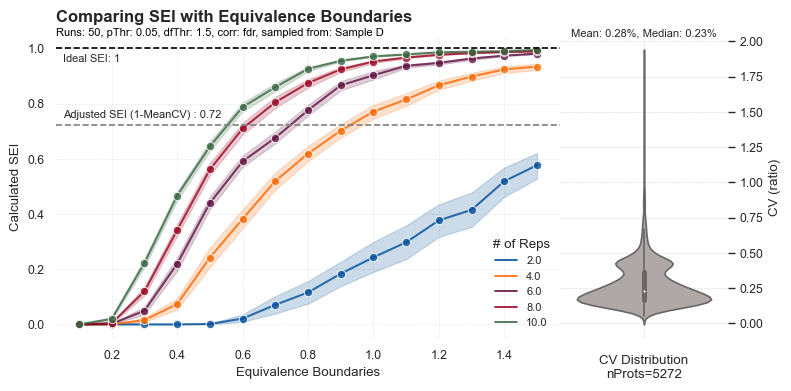

In [5]:
# Simulate and Visualize
eq_boundaries = np.linspace(0.1, 1.5, 15)
pThr = 0.05
corr = "fdr"
dfThr = 1.5
nRuns = 50

true_eq = 1
adjs_eq = 1 - np.mean(reference_cv_dist)

cols = reference_data.columns.tolist()
cv_mean = np.mean(reference_cv_dist )
cv_median = np.median(reference_cv_dist)

iterations = []
for eqThr in eq_boundaries:
    # for corr in [None, "fdr", "qvalue"]:
    for nReps in [2, 4, 6, 8, 10]:
        for i in range(nRuns):
            iterations.append([
                eqThr,  
                nReps, 
                i
            ])

print(f"Total iterations: {len(iterations)}")

def run_single_setup(cur_iter):
    eqThr, nReps, run = cur_iter
    # Select randomly the number of samples without overlap divided by 2
    group1 = np.random.choice(cols, nReps, replace=False)
    group2 = np.random.choice(list(set(cols) - set(group1)), nReps, replace=False)
    assert len(set(group1).intersection(set(group2))) == 0, "Overlap between samples"

    res_df, info_df = test.run_test(
        S1_arr = reference_data[group1].values,
        S2_arr = reference_data[group2].values,
        is_log2 = False,
        cv_thr = 10**5,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "RunID": run,
        "nReps": nReps,
        "B_eq": eqThr,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
    })


# Run the simulation
with Pool(32) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4), 
    # sharey=True, 
    gridspec_kw={
        "width_ratios": [3, 1],
        "wspace": 0,
    },
)

sns.lineplot(
    ax = ax[0],
    data=plot_data,
    x="B_eq",
    y="Calculated_EQ",
    hue="nReps",
    palette=def_colors,
    marker="o",
    markersize=6,
    linewidth=1.5,
    alpha=0.8,
)

ax[0].set_title(
    f"Comparing SEI with Equivalence Boundaries", 
    fontsize=12, 
    fontweight="bold",
    loc="left",
    pad=10
)
# Add annotation
ax[0].annotate(
    # Add description of the setup
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}, sampled from: {new_name}",
    # f"Data is created with {nReps} replicates from the same sample",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax[0].set_xlabel("Equivalence Boundaries")
ax[0].set_ylabel("Calculated SEI")

# True Equivalence Percentage
ax[0].axhline(
    y=true_eq,
    color="black",
    linestyle="--",
)
ax[0].text(
    0.05, true_eq - 0.05,
    f"Ideal SEI: {true_eq}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left',
)

# Expected with Technical Variability accounted
ax[0].axhline(
    y=adjs_eq,
    color="gray",
    linestyle="--",
)
ax[0].text(
    0.05, adjs_eq + 0.025,
    f"Adjusted SEI (1-MeanCV) : {adjs_eq:.2f}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left'
)

# Add grid
ax[0].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.5,
    linestyle = "--",
    linewidth = 0.5
)

# Add legend
ax[0].legend(
    title="# of Reps",
    loc="lower right",
    fontsize=8,
    frameon=False
)

# Add the CV distribution as violin plot to the right
sns.violinplot(
    data=reference_cv_dist,
    ax=ax[1],
    color=status_colors["Unexplained"]
)

ax[1].text(
    0.5, 1,
    f"Mean: {cv_mean:.2f}%, Median: {cv_median:.2f}%",
    fontsize=8,
    transform=ax[1].transAxes,
    horizontalalignment='center'
)

# ax[1].set_ylim(0, 100)
ax[1].set_xticks([0])
ax[1].set_xticklabels([""])
ax[1].set_ylabel("CV (ratio)")
ax[1].set_xlabel(f"CV Distribution\nnProts={len(reference_cv_dist)}")
# Place y-axis on the right
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[1].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "EquivalenceBoundarySimulation_NoCVThr_SingleSample_SpikeIn",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

We can see the data quality has significant effect on the boundary necessary to reach to the true biological equivalence of 100%. While this is not really reflects what the real data would achive that's why I also included the adjusted equivalence percentage by reducing the mean CV calculated from all proteins using all technical replicates for the reference sample. This allow us to set the boundaries to a more realistic level and capturing the proprotions of the equivalent proteins more accurately give the data quality. 

Another thing to highlight here is the number of replicates used in the testing. With lower number of replicates the effect of data quality is multiplied and to get to good boundary-percentage trade off is lowered and in the case of two is so large that would probably not be useful in practice. Lucky this dataset provides 23 tehcnical replicates for each biological sample which gives us opportunity to pick a lower boundary and still get a good percentage of equivalent proteins.

#### CV-based Filtering' Effect 

Because the intra-sample CV or data precision has significant impact on particularly on the equivalence testing we introduced a filtering of proteins based on intra-sample CV in the QuEStVar. This checks if either one or both groups' protein has above the given CV threshold and if so it removes the protein from the testing. In this introspective I will show how the CV-based filtering can effect the equivalence testing and how in turn effect the boundary selection process.

Total iterations: 3750


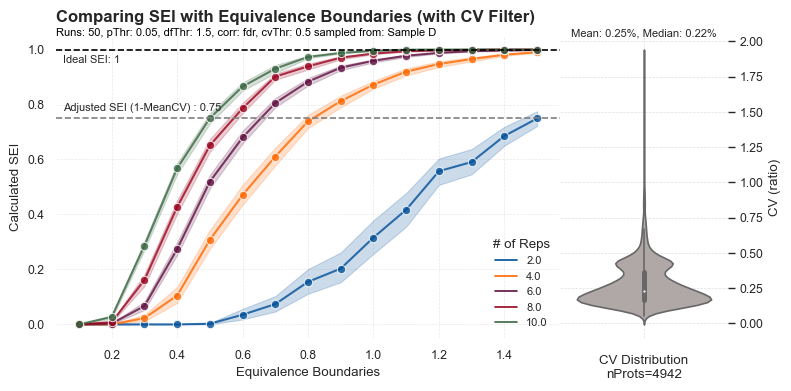

In [6]:
# Simulate and Visualize
eq_boundaries = np.linspace(0.1, 1.5, 15)
pThr = 0.05
corr = "fdr"
dfThr = 1.5
nRuns = 50
cvThr = 50

cols = reference_data.columns.tolist()
reference_cv_dist2 = reference_cv_dist[reference_cv_dist <= cvThr/100]
cv_mean = np.mean(reference_cv_dist2)
cv_median = np.median(reference_cv_dist2)

true_eq = 1
adjs_eq = true_eq - np.mean(reference_cv_dist2)

iterations = []
for eqThr in eq_boundaries:
    # for corr in [None, "fdr", "qvalue"]:
    for nReps in [2, 4, 6, 8, 10]:
        for i in range(nRuns):
            iterations.append([
                eqThr,  
                nReps, 
                i
            ])

print(f"Total iterations: {len(iterations)}")

def run_single_setup(cur_iter):
    eqThr, nReps, run = cur_iter
    # Select randomly the number of samples without overlap divided by 2
    group1 = np.random.choice(cols, nReps, replace=False)
    group2 = np.random.choice(list(set(cols) - set(group1)), nReps, replace=False)
    assert len(set(group1).intersection(set(group2))) == 0, "Overlap between samples"

    res_df, info_df = test.run_test(
        S1_arr = reference_data[group1].values,
        S2_arr = reference_data[group2].values,
        is_log2 = False,
        cv_thr = cvThr,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "RunID": run,
        "nReps": nReps,
        "B_eq": eqThr,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
    })


# Run the simulation
with Pool(32) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4), 
    # sharey=True, 
    gridspec_kw={
        "width_ratios": [3, 1],
        "wspace": 0,
    },
)

sns.lineplot(
    ax = ax[0],
    data=plot_data,
    x="B_eq",
    y="Calculated_EQ",
    hue="nReps",
    palette=def_colors,
    marker="o",
    markersize=6,
    linewidth=1.5,
    alpha=0.8,
)

ax[0].set_title(
    f"Comparing SEI with Equivalence Boundaries (with CV Filter)", 
    fontsize=12, 
    fontweight="bold",
    loc="left",
    pad=10
)
# Add annotation
ax[0].annotate(
    # Add description of the setup
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}, cvThr: {cvThr/100} sampled from: {new_name}",
    # f"Data is created with {nReps} replicates from the same sample",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax[0].set_xlabel("Equivalence Boundaries")
ax[0].set_ylabel("Calculated SEI")

# True Equivalence Percentage
ax[0].axhline(
    y=true_eq,
    color="black",
    linestyle="--",
)
ax[0].text(
    0.05, true_eq - 0.05,
    f"Ideal SEI: {true_eq}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left',
)

# Expected with Technical Variability accounted
ax[0].axhline(
    y=adjs_eq,
    color="gray",
    linestyle="--",
)
ax[0].text(
    0.05, adjs_eq + 0.025,
    f"Adjusted SEI (1-MeanCV) : {adjs_eq:.2f}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left'
)

# Add grid
ax[0].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.5,
    linestyle = "--",
    linewidth = 0.5
)

# Add legend
ax[0].legend(
    title="# of Reps",
    loc="lower right",
    fontsize=8,
    frameon=False
)

# Add the CV distribution as violin plot to the right
sns.violinplot(
    data=reference_cv_dist,
    ax=ax[1],
    color=status_colors["Unexplained"]
)

ax[1].text(
    0.5, 1,
    f"Mean: {cv_mean:.2f}%, Median: {cv_median:.2f}%",
    fontsize=8,
    transform=ax[1].transAxes,
    horizontalalignment='center'
)

# ax[1].set_ylim(0, 100)
ax[1].set_xticks([0])
ax[1].set_xticklabels([""])
ax[1].set_ylabel("CV (ratio)")
ax[1].set_xlabel(f"CV Distribution\nnProts={len(reference_cv_dist2)}")
# Place y-axis on the right
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[1].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "EquivalenceBoundarySimulation_50CVThr_SingleSample_SpikeIn",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

Using 50% CV threshold improves the percentages however this is not a great standalone solution since it will remove proteins from testing and depending on how string the threshold is set it can remove a lot of proteins from the testing. This can be a good solution if the data quality is not good and one wants to focus on only very reliably quantified proteins.

#### Aggregate All Samples to Determine Equivalence Boundaries

So far I've focused only on a single sample to highlight the logic of how to plot and determine the equivalence boundary. However the dataset consists of multiple samples and there should be a way to inform the boundaries incorporating all samples. Two ways to do this is to visualize each sample the same way and manually determine the boundary that would be good for all samples. Additionally I will create the mean values for each runs at equivalence boundaries then plot them in a scatter+line plot from each sample to determine a best boundary. 



Mean of Mean CVs from Each Sample: 0.23367282061014064


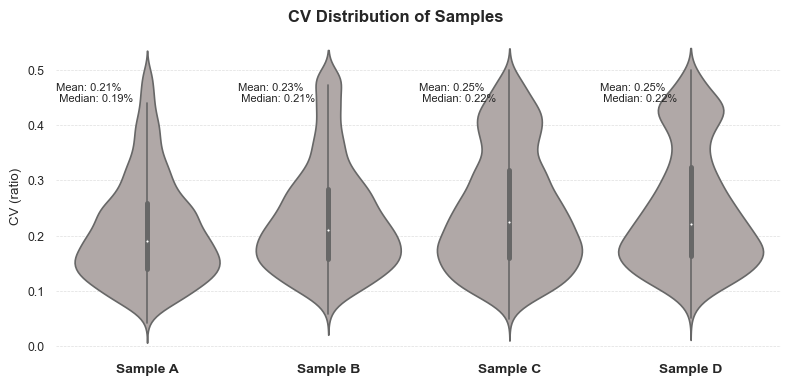

In [14]:
cvThr = 50
new_name_dict = {
    "1-06": "Sample D",
    "1-12": "Sample C",
    "1-25": "Sample B",
    "Lymphnode": "Sample A",
}
cv_data = {}
ref_data = {}
for sample_name in ["1-06", "1-12", "1-25", "Lymphnode"]:
    reference_data = feather.read_dataframe(
        f"../2022_Frohlich/data/processed/samples/{sample_name}.feather"
    ).dropna()
    
    reference_cv_dist = utils.cv_numpy(
        x = reference_data.values,
        format = "percent"
    )
    reference_cv_dist = reference_cv_dist[reference_cv_dist <= cvThr]
    cv_data[sample_name] = reference_cv_dist
    
    ref_data[sample_name] = reference_data

# CV Violin Plot
fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(8, 4), 
    sharey=True,
    gridspec_kw={
        "wspace": 0,
    },
)
cv_means = []
for i, sample_name in enumerate(["1-06", "1-12", "1-25", "Lymphnode"][::-1]):
    cv_mean = np.nanmean(cv_data[sample_name]) / 100
    cv_median = np.nanmedian(cv_data[sample_name]) / 100
    sns.violinplot(
        data=cv_data[sample_name] / 100,
        ax=ax[i],
        color=status_colors["Unexplained"]
    )

    ax[i].set_xlabel(
        f"{new_name_dict[sample_name]}",
        fontsize=10,
        fontweight="bold",
        # loc="left",
        # pad=10
    )
    ax[i].set_xticks([])

    ax[i].text(
        0, .85,
        f"Mean: {cv_mean:.2f}%\n Median: {cv_median:.2f}%",
        fontsize=8,
        transform=ax[i].transAxes,
        horizontalalignment='left',
        verticalalignment='top'
    )

    # ax[i].set_ylim(0, 100)
    ax[i].grid(
        axis = "both",
        color = "lightgray",
        alpha = 0.75,
        linestyle = "--",
        linewidth = 0.5
    )
    cv_means.append(cv_mean)

print(f"Mean of Mean CVs from Each Sample: {np.mean(cv_means)}")

# Add y-axis label
ax[0].set_ylabel("CV (ratio)")

sns.despine(
    left = True,
    bottom = True
)

fig.suptitle(
    "CV Distribution of Samples",
    fontsize=12,
    fontweight="bold",
    y=.95
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "CVDistribution_Filt_50CVThr_SingleSample_SpikeIn",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

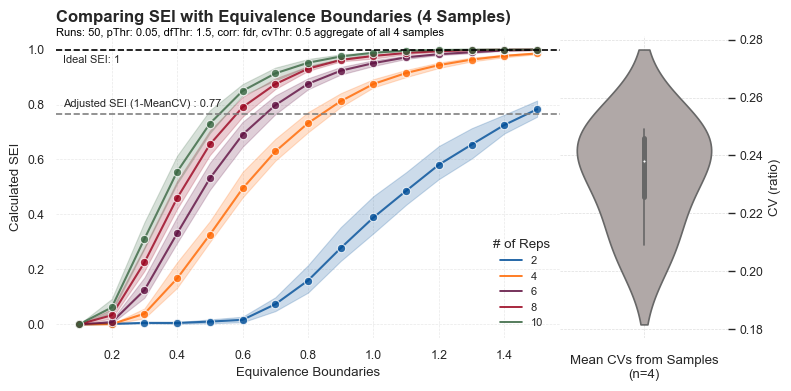

In [16]:
# Simulate and Visualize
eq_boundaries = np.linspace(0.1, 1.5, 15)
pThr = 0.05
corr = "fdr"
dfThr = 1.5
nRuns = 50
cvThr = 50
true_eq = 1
adjs_eq = 1 - np.mean(cv_means)

iterations = []
for sample_name in ["1-06", "1-12", "1-25", "Lymphnode"]:
    for eqThr in eq_boundaries:
        for nReps in [2, 4, 6, 8, 10]:
            for i in range(nRuns):
                iterations.append([
                    sample_name,
                    eqThr,  
                    nReps, 
                    i
                ])


plot_data = pd.DataFrame()


def run_single_setup(cur_iter):
    sample_name, eqThr, nReps, run = cur_iter
    reference_data = ref_data[sample_name]
    cols = reference_data.columns.tolist()
    # Select randomly the number of samples without overlap divided by 2
    group1 = np.random.choice(cols, nReps, replace=False)
    group2 = np.random.choice(list(set(cols) - set(group1)), nReps, replace=True)
    assert len(set(group1).intersection(set(group2))) == 0, "Overlap between samples"
    
    res_df, info_df = test.run_test(
        S1_arr = reference_data[group1].values,
        S2_arr = reference_data[group2].values,
        is_log2 = False,
        cv_thr = cvThr,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "Sample": sample_name,
        "RunID": run,
        "nReps": nReps,
        "B_eq": eqThr,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
    })

# Run the simulation
with Pool(32) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4), 
    # sharey=True, 
    gridspec_kw={
        "width_ratios": [3, 1],
        "wspace": 0,
    },
)

plot_data_2 = plot_data.groupby(["Sample", "nReps", "B_eq"]).mean().reset_index()

sns.lineplot(
    ax = ax[0],
    data=plot_data_2,
    x="B_eq",
    y="Calculated_EQ",
    hue="nReps",
    palette=def_colors,
    marker="o",
    markersize=6,
    linewidth=1.5,
    alpha=0.8,
)

ax[0].set_title(
    "Comparing SEI with Equivalence Boundaries (4 Samples)", 
    fontsize=12, 
    fontweight="bold",
    loc="left",
    pad=10
)

# Add annotation
ax[0].annotate(
    # Add description of the setup
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}, cvThr: {cvThr/100} aggregate of all 4 samples",
    # f"Data is created with {nReps} replicates from the same sample",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax[0].set_xlabel("Equivalence Boundaries")
ax[0].set_ylabel("Calculated SEI")

# True Equivalence Percentage
ax[0].axhline(
    y=true_eq,
    color="black",
    linestyle="--",
)
ax[0].text(
    0.05, true_eq - 0.05,
    f"Ideal SEI: {true_eq}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left',
)

# Expected with Technical Variability accounted
ax[0].axhline(
    y=adjs_eq,
    color="gray",
    linestyle="--",
)
ax[0].text(
    0.05, adjs_eq + 0.025,
    f"Adjusted SEI (1-MeanCV) : {adjs_eq:.2f}",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left'
)

ax[0].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.5,
    linestyle = "--",
    linewidth = 0.5
)

# Add legend
ax[0].legend(
    title="# of Reps",
    loc="lower right",
    fontsize=8,
    frameon=False
)

# Add the CV distribution as violin plot to the right
sns.violinplot(
    data=cv_means,
    ax=ax[1],
    color=status_colors["Unexplained"]
)

# ax[1].set_ylim(0, 100)
ax[1].set_xticks([0])
ax[1].set_xticklabels([""])
ax[1].set_ylabel("CV (ratio)")
ax[1].set_xlabel(f"Mean CVs from Samples\n(n={len(cv_means)})")
# Place y-axis on the right
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[1].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "EquivalenceBoundarySimulation_50CVThr_Aggregate_SpikeIn",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

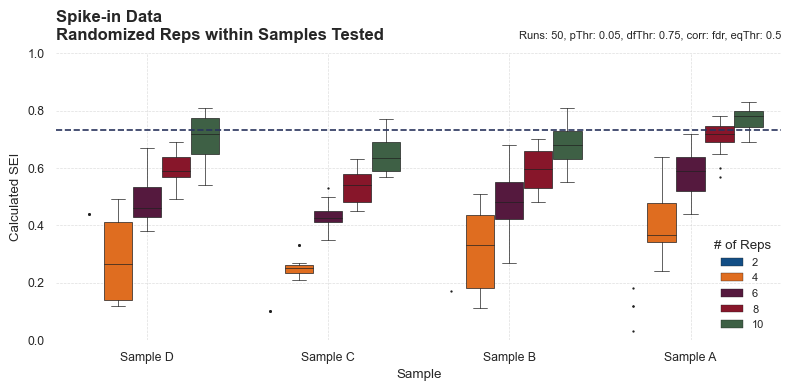

In [20]:
# Simulate and Visualize
eq_boundaries = np.linspace(0.1, 1.5, 15)
pThr = 0.05
corr = "fdr"
dfThr = 0.75
eqThr = 0.50
nRuns = 50
cvThr = 75
true_eq = 1
adjs_eq = 1 - np.mean(cv_means)/100

iterations = []

for sample_name in ["1-06", "1-12", "1-25", "Lymphnode"]:
    for nReps in [2, 4, 6, 8, 10]:
        for i in range(nRuns):
            iterations.append([
                sample_name,
                nReps, 
                i
            ])


plot_data = pd.DataFrame()


def run_single_setup(cur_iter):
    sample_name, nReps, run = cur_iter

    reference_data = ref_data[sample_name]
    cols = reference_data.columns.tolist()
   # Select randomly the select nReps columns for both groups
    group1 = np.random.choice(cols, nReps, replace=True)
    group2 = np.random.choice(cols, nReps, replace=True)
    
    res_df, info_df = test.run_test(
        S1_arr = reference_data[group1].values,
        S2_arr = reference_data[group2].values,
        is_log2 = False,
        cv_thr = 10**5,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "Sample": sample_name,
        "RunID": run,
        "nReps": nReps,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
    })

# Run the simulation
with Pool(32) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T
plot_data["Sample"] = plot_data["Sample"].map(new_name_dict)

fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 4), 
)

sns.boxplot(
    ax = ax,
    data=plot_data,
    x="Sample",
    y="Calculated_EQ",
    hue="nReps",
    palette=def_colors,
    linewidth=0.5,
    fliersize=0.75,
)

ax.text(
    1, 1.05,
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}, eqThr: {eqThr}",
    fontsize=8,
    transform=ax.transAxes,
    horizontalalignment='right'
)

ax.set_title(
    "Spike-in Data \nRandomized Reps within Samples Tested",
    fontsize=12,
    fontweight="bold",
    loc="left",
    pad=10
)
ax.set_ylim(0, 1)
ax.set_xlabel("Sample")
ax.set_ylabel("Calculated SEI")

# Expected with Technical Variability accounted
ax.axhline(
    y=adjs_eq,
    color=status_colors["Equivalent"],
    linestyle="--",
)
# Add grid
ax.grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)
# Add legend
ax.legend(
    title="# of Reps",
    loc="lower right",
    fontsize=8,
    frameon=False
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

In the boxplot I've shown the equivalence percentage calculated from the specific 0.5 equivalence boundary and 0.75 as the difference boundary.

---

## Cancer Cell Line Data

In [10]:
samples_folder = "../2022_Goncalves/data/processed/samples/"
samples = os.listdir(samples_folder)
data_dict = {}
for sample in samples:
    data_dict[sample.strip(".feather")] = feather.read_dataframe(
        os.path.join(samples_folder, sample)
    ).dropna()

Total iterations: 54000


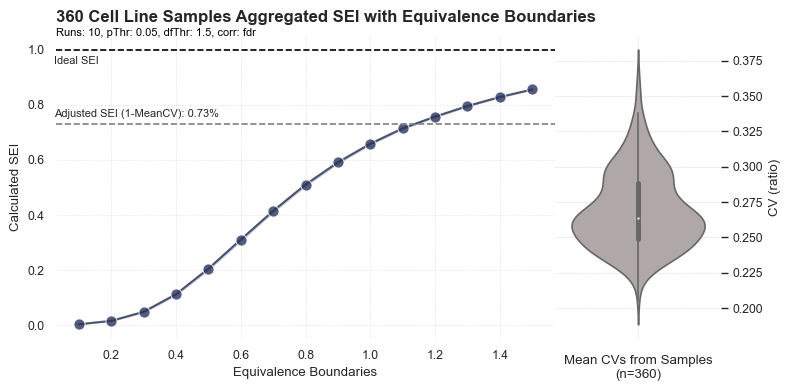

In [13]:
# Creating 
eq_boundaries = np.linspace(0.1, 1.5, 15)
nReps = 3
pThr = 0.05
corr = "fdr"
dfThr = 1.5
nRuns = 10
cvThr = 10**5

iterations = []
for eqThr in eq_boundaries:
    for sample_name, sample_data in data_dict.items():
        for i in range(nRuns):
            iterations.append([
                sample_name,
                sample_data,
                eqThr,
                i
            ])

print(f"Total iterations: {len(iterations)}")

def run_single_setup(cur_iter):
    sample_name, sample_data, eqThr, run = cur_iter
    cols = sample_data.columns.tolist()
    cv_mean = np.nanmean(utils.cv_numpy(sample_data.values, format="percent"))
    # Select randomly the number of samples 
    group1 = np.random.choice(cols, nReps, replace=True)
    group2 = np.random.choice(cols, nReps, replace=True)

    res_df, info_df = test.run_test(
        S1_arr = sample_data[group1].values,
        S2_arr = sample_data[group2].values,
        is_log2 = False,
        cv_thr = cvThr,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "Sample": sample_name,
        "RunID": run,
        "B_eq": eqThr,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
        "CV_Mean": cv_mean
    })

# Run the simulation
with Pool(30) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T
plot_data["B_eq"] = plot_data["B_eq"].astype(float) 
cv_means = plot_data.groupby(["Sample"])["CV_Mean"].mean().values
adjs_eq = 1 - np.nanmean(cv_means)/100

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4), 
    # sharey=True, 
    gridspec_kw={
        "width_ratios": [3, 1],
        "wspace": 0,
    },
)

sns.lineplot(
    ax = ax[0],
    data=plot_data,
    x="B_eq",
    y="Calculated_EQ",
    color=status_colors["Equivalent"],
    marker="o",
    markersize=8,
    linewidth=1.5,
    alpha=0.8,
)

ax[0].set_title(
    "360 Cell Line Samples Aggregated SEI with Equivalence Boundaries", 
    fontsize=12, 
    fontweight="bold",
    loc="left",
    pad=10
)

# Add annotation
ax[0].annotate(
    # Add description of the setup
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}",
    # f"Data is created with {nReps} replicates from the same sample",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax[0].set_xlabel("Equivalence Boundaries")
ax[0].set_ylabel("Calculated SEI")

# # Set xticks to the boundaries
# ax[0].set_xticks(eq_boundaries)
# ax[0].set_xticklabels(eq_boundaries)

# True Equivalence Percentage
ax[0].axhline(
    y=1,
    color="black",
    linestyle="--",
)
ax[0].text(
    0.025, 1 - 0.05,
    f"Ideal SEI",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left',
)

# Expected with Technical Variability accounted
ax[0].axhline(
    y=adjs_eq,
    color="gray",
    linestyle="--",
)
ax[0].text(
    0.025, adjs_eq + 0.025,
    f"Adjusted SEI (1-MeanCV): {adjs_eq:.2f}%",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left'
)

# Add grid
ax[0].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.5,
    linestyle = "--",
    linewidth = 0.5
)

# Add the CV distribution as violin plot to the right
sns.violinplot(
    data=cv_means/100,
    ax=ax[1],
    color=status_colors["Unexplained"]
)

# ax[1].set_ylim(0, 100)
ax[1].set_xticks([0])
ax[1].set_xticklabels([""])
ax[1].set_ylabel("CV (ratio)")
ax[1].set_xlabel(f"Mean CVs from Samples\n(n={len(cv_means)})")
# Place y-axis on the right
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[1].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "EquivalenceBoundarySimulation_NoCVThr_Aggregate_CancerCellLine",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )

Total iterations: 54000


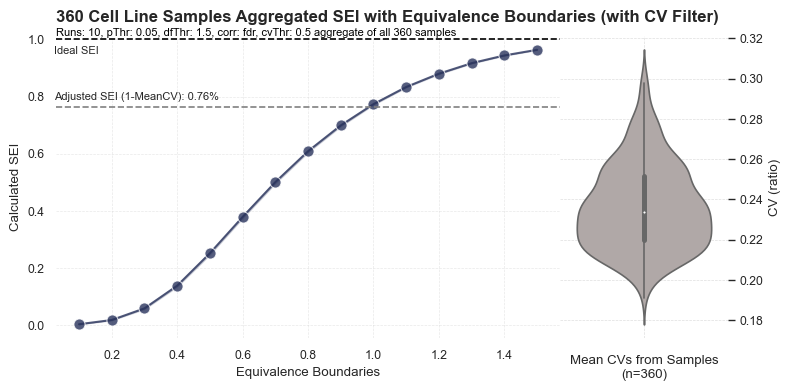

In [16]:
# Creating 
eq_boundaries = np.linspace(0.1, 1.5, 15)
nReps = 3
pThr = 0.05
corr = "fdr"
dfThr = 1.5
nRuns = 10
cvThr = 50

iterations = []
for eqThr in eq_boundaries:
    for sample_name, sample_data in data_dict.items():
        for i in range(nRuns):
            iterations.append([
                sample_name,
                sample_data,
                eqThr,
                i
            ])

print(f"Total iterations: {len(iterations)}")

def run_single_setup(cur_iter):
    sample_name, sample_data, eqThr, run = cur_iter
    cols = sample_data.columns.tolist()
    x = (utils.cv_numpy(sample_data.values, format="percent"))#.mean()
    cv_mean = x[x <= cvThr].mean()
    # Select randomly the number of samples 
    group1 = np.random.choice(cols, nReps, replace=True)
    group2 = np.random.choice(cols, nReps, replace=True)

    res_df, info_df = test.run_test(
        S1_arr = sample_data[group1].values,
        S2_arr = sample_data[group2].values,
        is_log2 = False,
        cv_thr = cvThr,
        p_thr = pThr,
        df_thr = dfThr,
        eq_thr = eqThr,
        var_equal = True,
        is_paired = False,
        correction = corr,
    )

    tmp = res_df["Status"].value_counts(
        normalize=True
    ).mul(1).round(2).reindex(
        [-1, 0, 1,], 
        fill_value=0
    )

    df_pct = tmp.loc[-1]
    eq_pct = tmp.loc[1]
    ux_pct = tmp.loc[0]

    return pd.Series({
        "Sample": sample_name,
        "RunID": run,
        "B_eq": eqThr,
        "Calculated_EQ": eq_pct,
        "Calculated_DF": df_pct,
        "Calculated_UX": ux_pct,
        "CV_Mean": cv_mean
    })

# Run the simulation
with Pool(30) as p:
    tmp = p.map(run_single_setup, iterations)

plot_data = pd.concat(tmp, axis=1).T
plot_data["B_eq"] = plot_data["B_eq"].astype(float) 
cv_means = plot_data.groupby(["Sample"])["CV_Mean"].mean().values
adjs_eq = 1 - np.nanmean(cv_means)/100

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8, 4), 
    # sharey=True, 
    gridspec_kw={
        "width_ratios": [3, 1],
        "wspace": 0,
    },
)

sns.lineplot(
    ax = ax[0],
    data=plot_data,
    x="B_eq",
    y="Calculated_EQ",
    color=status_colors["Equivalent"],
    marker="o",
    markersize=8,
    linewidth=1.5,
    alpha=0.8,
)

ax[0].set_title(
    "360 Cell Line Samples Aggregated SEI with Equivalence Boundaries (with CV Filter)", 
    fontsize=12, 
    fontweight="bold",
    loc="left",
    pad=10
)

# Add annotation
ax[0].annotate(
    # Add description of the setup
    f"Runs: {nRuns}, pThr: {pThr}, dfThr: {dfThr}, corr: {corr}, cvThr: {cvThr/100} aggregate of all 360 samples",
    # f"Data is created with {nReps} replicates from the same sample",
    xy = (0, 1),
    xycoords = "axes fraction",
    fontsize = 8,
    color = "black"
)

ax[0].set_xlabel("Equivalence Boundaries")
ax[0].set_ylabel("Calculated SEI")

# # Set xticks to the boundaries
# ax[0].set_xticks(eq_boundaries)
# ax[0].set_xticklabels(eq_boundaries)

# True Equivalence Percentage
ax[0].axhline(
    y=1,
    color="black",
    linestyle="--",
)
ax[0].text(
    0.025, 1 - 0.05,
    f"Ideal SEI",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left',
)

# Expected with Technical Variability accounted
ax[0].axhline(
    y=adjs_eq,
    color="gray",
    linestyle="--",
)
ax[0].text(
    0.025, adjs_eq + 0.025,
    f"Adjusted SEI (1-MeanCV): {adjs_eq:.2f}%",
    fontsize=8,
    # transform=ax[0].transAxes,
    horizontalalignment='left'
)

# Add grid
ax[0].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.5,
    linestyle = "--",
    linewidth = 0.5
)

# Add the CV distribution as violin plot to the right
sns.violinplot(
    data=cv_means/100,
    ax=ax[1],
    color=status_colors["Unexplained"]
)

# ax[1].set_ylim(0, 100)
ax[1].set_xticks([0])
ax[1].set_xticklabels([""])
ax[1].set_ylabel("CV (ratio)")
ax[1].set_xlabel(f"Mean CVs from Samples\n(n={len(cv_means)})")
# Place y-axis on the right
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[1].grid(
    axis = "both",
    color = "lightgray",
    alpha = 0.75,
    linestyle = "--",
    linewidth = 0.5
)

sns.despine(
    left = True,
    bottom = True
)

plt.tight_layout()

# Save the figure, if save_to_folder is True
if save_to_folder:
    plots.save_figures(
        fig_obj = plt.gcf(),
        filename = "EquivalenceBoundarySimulation_50CVThr_Aggregate_CancerCellLine",
        filepath = fig_path,
        fileformat = figure_formats,
        dpi = figure_dpi,
        transparent = transparet_bg
    )